In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, binomtest, norm
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier
import shap

pd.set_option("display.width", 120)
np.random.seed(42)

C:\Users\mayar\OneDrive\Desktop\ATUTEB 2026 (IDA vs BTM)\crispy-xylophone\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ===== Chargement unique des donnees (une seule fois dans tout le notebook) =====
DATA_PATH = "data/base apres nettoyage.xlsx"

data = pd.read_excel(DATA_PATH)
data.columns = data.columns.str.strip()

# Nettoyage du texte AVANT tout mapping
data["Diagnosis"] = data["Diagnosis"].astype(str).str.strip().str.lower()
data["Sex"] = data["Sex"].astype(str).str.strip().str.lower()

print("Valeurs uniques de Diagnosis apres nettoyage :")
print(data["Diagnosis"].value_counts())

DIAGNOSIS_MAP = {
    "iron deficiency anemia": ("IDA", 0),
    "beta-thalassemia minor": ("BTM", 1),
}

data["label"] = data["Diagnosis"].map(lambda d: DIAGNOSIS_MAP.get(d, (None, None))[0])
data["target"] = data["Diagnosis"].map(lambda d: DIAGNOSIS_MAP.get(d, (None, None))[1])

excluded = data[data["label"].isna()]
if len(excluded):
    print(f"\n{len(excluded)} ligne(s) hors cohorte IDA/BTM exclue(s) (diagnostic non reconnu) :")
    print(excluded["Diagnosis"].value_counts())

data = data.dropna(subset=["target"]).copy()
data["target"] = data["target"].astype(int)

print(f"\nCohorte finale : {len(data)} patients")
print(data["label"].value_counts())

Valeurs uniques de Diagnosis apres nettoyage :
Diagnosis
iron deficiency anemia    271
beta-thalassemia minor     60
Name: count, dtype: int64

Cohorte finale : 331 patients
label
IDA    271
BTM     60
Name: count, dtype: int64


In [3]:
# ===== TABLE I : CARACTERISTIQUES DEMOGRAPHIQUES =====
btm = data[data["label"] == "BTM"]
ida = data[data["label"] == "IDA"]

age_btm_mean, age_btm_sd = btm["Age"].mean(), btm["Age"].std()
age_ida_mean, age_ida_sd = ida["Age"].mean(), ida["Age"].std()
_, p_age = mannwhitneyu(btm["Age"].dropna(), ida["Age"].dropna())


def sex_counts(df):
    total = len(df)
    female = int((df["Sex"] == "f").sum())
    male = int((df["Sex"] == "m").sum())
    return female, male, total


btm_f, btm_m, btm_n = sex_counts(btm)
ida_f, ida_m, ida_n = sex_counts(ida)

contingency = pd.crosstab(data["label"], data["Sex"])
_, p_sex = stats.fisher_exact(contingency.values)

table1 = pd.DataFrame({
    "": ["Age (years)", "Sex - Female n(%)", "Sex - Male n(%)"],
    f"BTM (n={btm_n})": [
        f"{age_btm_mean:.1f} +/- {age_btm_sd:.1f}",
        f"{btm_f} ({btm_f/btm_n*100:.1f}%)",
        f"{btm_m} ({btm_m/btm_n*100:.1f}%)",
    ],
    f"IDA (n={ida_n})": [
        f"{age_ida_mean:.1f} +/- {age_ida_sd:.1f}",
        f"{ida_f} ({ida_f/ida_n*100:.1f}%)",
        f"{ida_m} ({ida_m/ida_n*100:.1f}%)",
    ],
    "p-value": [f"{p_age:.3f}", f"{p_sex:.3f}", ""],
})
print("Test statistique : Mann-Whitney U (age) et Fisher exact (sexe)\n")
print(table1.to_string(index=False))

Test statistique : Mann-Whitney U (age) et Fisher exact (sexe)

                     BTM (n=60)   IDA (n=271) p-value
      Age (years) 45.5 +/- 14.1 43.4 +/- 16.2   0.152
Sex - Female n(%)    47 (78.3%)   230 (84.9%)   0.246
  Sex - Male n(%)    13 (21.7%)    41 (15.1%)        


In [4]:
# ===== TABLE II : COMPARAISON DES PARAMETRES HEMATOLOGIQUES =====
HEMATO_VARS = [
    "RBC", "Hb", "HCT", "MCV", "MCH", "MCHC",
    "PLT", "RDW-SD", "RDW-CV",
    "NEUT", "LYMPH", "MONO", "EO", "BASO",
    "RET %", "RET absolute",
    "IRF", "LFR", "MFR", "HFR",
]

UNIT_CONVERSIONS = {
    "PLT": 1e3, "NEUT": 1e3, "LYMPH": 1e3, "MONO": 1e3, "EO": 1e3, "BASO": 1e3,
    "RET absolute": 1e6,
}
UNIT_LABELS = {
    "PLT": " (x10^3/uL)", "NEUT": " (x10^3/uL)", "LYMPH": " (x10^3/uL)",
    "MONO": " (x10^3/uL)", "EO": " (x10^3/uL)", "BASO": " (x10^3/uL)",
    "RET absolute": " (x10^6/uL)",
}


def median_iqr(x):
    x = x.dropna()
    return f"{x.median():.2f} ({x.quantile(0.25):.2f}-{x.quantile(0.75):.2f})"


rows = []
for var in HEMATO_VARS:
    if var not in data.columns:
        continue
    factor = UNIT_CONVERSIONS.get(var, 1)
    ida_vals = ida[var] / factor
    btm_vals = btm[var] / factor
    if ida_vals.dropna().shape[0] < 3 or btm_vals.dropna().shape[0] < 3:
        continue
    _, p = mannwhitneyu(ida_vals.dropna(), btm_vals.dropna())
    rows.append({
        "Feature": var + UNIT_LABELS.get(var, ""),
        "IDA (Median [Q1-Q3])": median_iqr(ida_vals),
        "BTM (Median [Q1-Q3])": median_iqr(btm_vals),
        "p-value": "<0.001" if p < 0.001 else f"{p:.3f}",
    })

table2 = pd.DataFrame(rows)
print(table2.to_string(index=False))

                Feature   IDA (Median [Q1-Q3])   BTM (Median [Q1-Q3]) p-value
                    RBC       4.27 (3.83-4.56)       5.19 (4.81-5.60)  <0.001
                     Hb       8.50 (7.05-9.60)     10.30 (9.60-11.10)  <0.001
                    HCT    29.10 (25.25-31.90)    31.35 (30.15-34.15)  <0.001
                    MCV    67.70 (64.10-73.45)    61.10 (59.42-65.03)  <0.001
                    MCH    19.70 (17.55-22.10)    19.65 (19.10-20.70)   0.795
                   MCHC    29.00 (27.45-30.70)    32.35 (31.77-32.90)  <0.001
         PLT (x10^3/uL) 294.00 (237.00-370.50) 221.50 (173.25-274.25)  <0.001
                 RDW-SD    46.10 (42.75-51.42)    35.80 (34.48-38.10)  <0.001
                 RDW-CV    19.70 (17.92-22.27)    17.10 (15.97-18.32)  <0.001
        NEUT (x10^3/uL)       3.37 (2.54-4.27)       4.21 (2.77-5.66)   0.002
       LYMPH (x10^3/uL)       1.91 (1.49-2.25)       2.17 (1.76-2.46)   0.001
        MONO (x10^3/uL)       0.55 (0.43-0.68)       0.51 (0.40-

In [5]:
# ===== 13 INDICES HEMATOLOGIQUES CLASSIQUES =====
# Formules / cutoffs / sens verifies contre les publications originales
# (voir document Methods pour les references completes).
INDEX_DEFINITIONS = {
    "Mentzer":    (lambda d: d["MCV"] / d["RBC"],                                13,    "below"),
    "RDWI":       (lambda d: (d["MCV"] * d["RDW-CV"]) / d["RBC"],                220,   "below"),
    "Srivastava": (lambda d: d["MCH"] / d["RBC"],                                3.8,   "below"),
    "S&L":        (lambda d: (d["MCV"] ** 2 * d["MCH"]) / 100,                   1530,  "below"),
    "E&F":        (lambda d: d["MCV"] - d["RBC"] - (5 * d["Hb"]) - 3.4,          0,     "below"),
    "G&K":        (lambda d: (d["MCV"] ** 2 * d["RDW-CV"]) / (d["Hb"] * 100),    65,    "below"),
    "Ricerca":    (lambda d: d["RDW-CV"] / d["RBC"],                             4.4,   "below"),
    "Sirdah":     (lambda d: d["MCV"] - d["RBC"] - (3 * d["Hb"]),                27,    "below"),
    "Ehsani":     (lambda d: d["MCV"] - (10 * d["RBC"]),                        15,     "below"),
    # CRUISE = MCHC + 0.603*RBC + 0.523*RDW-CV, cutoff 42.63
    # (Hans A, Atreja CB, Batra N. Cureus. 2024;16(7):e64048 ;
    #  Jahangiri M, Rahim F, Malehi AS. Sci Rep. 2019;9(1):18610)
    "CRUISE":     (lambda d: d["MCHC"] + 0.603 * d["RBC"] + 0.523 * d["RDW-CV"], 42.63, "above"),
    # MDHL = MCH*RBC/MCV, cutoff 1.67 (Telmissani OA et al. Lab Hematol. 1999;5:149-52)
    "MDHL":       (lambda d: (d["MCH"] * d["RBC"]) / d["MCV"],                   1.67,  "above"),
    # Huber-Herklotz = (MCH*RDW*0.1/RBC)+RDW, cutoff 22
    # (Huber A et al. Forum Med Suisse. 2004;4:947-952)
    # Concu a l'origine pour l'alpha-thalassemie -> performance attendue plus
    # faible ici (cohorte beta-thalassemie), a mentionner en discussion.
    "HH":         (lambda d: (d["MCH"] * d["RDW-CV"] * 0.1 / d["RBC"]) + d["RDW-CV"], 22, "below"),
    # MCHD = MCH/MCV, cutoff 0.34, BTM si <0.34 (Telmissani OA et al., 1999)
    # Sens original conserve fidelement, meme si moins performant sur cette
    # cohorte specifique (voir Discussion / limites).
    "MCHD":       (lambda d: d["MCH"] / d["MCV"],                                0.34,  "below"),
}


def index_score(d, name):
    """Retourne une valeur ou un score plus eleve = plus probable BTM."""
    formula, _, direction = INDEX_DEFINITIONS[name]
    value = formula(d)
    return value if direction == "above" else -value


indices = pd.DataFrame(index=data.index)
for name, (formula, cutoff, direction) in INDEX_DEFINITIONS.items():
    value = formula(data)
    indices[name] = value
    indices[f"{name}_pred"] = (
        (value > cutoff) if direction == "above" else (value < cutoff)
    ).astype(int)
indices["target"] = data["target"].values

rows = []
for name in INDEX_DEFINITIONS:
    mask = indices[name].notna()
    y_true = indices.loc[mask, "target"]
    y_pred = indices.loc[mask, f"{name}_pred"]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    acc = (tp + tn) / len(y_true)
    auc = roc_auc_score(y_true, index_score(data.loc[mask], name))
    rows.append({
        "Index": name, "Sensitivity (%)": round(sens * 100, 1),
        "Specificity (%)": round(spec * 100, 1), "Accuracy": round(acc, 3),
        "AUC": round(auc, 3),
    })

index_perf = pd.DataFrame(rows).sort_values("AUC", ascending=False)
print("Evaluation brute des indices (un seul cutoff univarie, avant modelisation) :\n")
print(index_perf.to_string(index=False))

Evaluation brute des indices (un seul cutoff univarie, avant modelisation) :

     Index  Sensitivity (%)  Specificity (%)  Accuracy   AUC
       G&K             61.7             98.9     0.919 0.970
       E&F             41.7            100.0     0.894 0.960
    Sirdah             58.3             98.5     0.912 0.957
      RDWI             76.7             98.5     0.944 0.955
      MDHL             55.0            100.0     0.918 0.952
   Ricerca             95.0             58.0     0.649 0.928
   Mentzer             66.7             93.4     0.885 0.914
    Ehsani             63.3             90.8     0.858 0.910
        HH             18.3             98.9     0.839 0.891
    CRUISE             85.0             62.2     0.665 0.803
Srivastava             51.7             88.6     0.819 0.790
       S&L            100.0              4.1     0.215 0.677
      MCHD             98.3              0.7     0.184 0.098


In [6]:
# ===== Variables d'entree pour les modeles ML : 20 variables hematologiques =====
# (sans "Age" ni "WBC", qui ne font pas partie des parametres NFS retenus)
FEATURES = HEMATO_VARS

missing_counts = data[FEATURES].isnull().sum()
print("Valeurs manquantes par variable (cohorte complete) :")
print(missing_counts[missing_counts > 0] if missing_counts.any() else "Aucune")

X = data[FEATURES].copy()
y = data["target"].copy()

X = X.fillna(X.median())

print(f"\nX: {X.shape}, y: {y.shape}")

Valeurs manquantes par variable (cohorte complete) :
RDW-SD    9
RDW-CV    9
NEUT      1
LYMPH     1
MONO      1
EO        1
BASO      1
HFR       1
dtype: int64

X: (331, 20), y: (331,)


In [7]:
# ===== VIF (multicolinearite) sur le sous-ensemble des variables MCV-liees =====
VIF_FEATURES = ["RBC", "Hb", "HCT", "MCV", "MCH", "MCHC", "RDW-CV"]
X_vif = X[VIF_FEATURES]

vif_data = pd.DataFrame({
    "Variable": VIF_FEATURES,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
}).sort_values("VIF", ascending=False)

print(vif_data.to_string(index=False))
print("\nVIF < 1.5 : absence de colinearite significative")
print("VIF 1-5 : colinearite moderee, generalement non problematique")
print("VIF > 10 : colinearite forte, necessitant une action corrective")

Variable         VIF
     MCH 8522.678532
     HCT 5531.224053
      Hb 4441.453336
     MCV 4182.225759
    MCHC 3322.384217
     RBC 3126.777506
  RDW-CV   46.586099

VIF < 1.5 : absence de colinearite significative
VIF 1-5 : colinearite moderee, generalement non problematique
VIF > 10 : colinearite forte, necessitant une action corrective


In [8]:
# ===== Definition unique des 2 modeles ML (reutilisee partout dans le notebook) =====
def make_xgboost():
    return XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        eval_metric="auc", random_state=42,
    )


def make_elastic_net():
    # l1_ratio en (0, 1) implique une regularisation elasticnet (L1+L2) avec le
    # solveur saga ; on ne passe pas "penalty=" explicitement (deprecie dans
    # les versions recentes de scikit-learn).
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            solver="saga", l1_ratio=0.5,
            max_iter=10000, random_state=42,
        )),
    ])


def youden_threshold(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    return thresholds[np.argmax(tpr - fpr)]


def binary_metrics(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    npv = tn / (tn + fn) if (tn + fn) else 0.0
    acc = (tp + tn) / (tp + tn + fp + fn)
    f1 = 2 * prec * sens / (prec + sens) if (prec + sens) else 0.0
    auc = roc_auc_score(y_true, y_proba)
    return dict(accuracy=acc, sensitivity=sens, specificity=spec,
                precision=prec, npv=npv, f1=f1, auc=auc)

In [9]:
# ===== Boucle d'evaluation Monte Carlo unifiee =====
N_ITER = 1000
cv = StratifiedShuffleSplit(n_splits=N_ITER, test_size=0.2, random_state=42)

model_metrics = {"XGBoost": [], "Elastic Net": []}
index_metrics = {name: [] for name in INDEX_DEFINITIONS}

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    for label, make_model in [("XGBoost", make_xgboost), ("Elastic Net", make_elastic_net)]:
        model = make_model()
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]
        thr = youden_threshold(y_test, proba)
        pred = (proba > thr).astype(int)
        model_metrics[label].append(binary_metrics(y_test, pred, proba))

    data_test = data.loc[X_test.index]
    indices_test = indices.loc[X_test.index]
    for name in INDEX_DEFINITIONS:
        mask = data_test[["RBC", "MCV", "Hb", "MCH", "RDW-CV"]].notna().all(axis=1)
        if mask.sum() < 2:
            continue
        y_test_masked = y_test[mask]
        if len(np.unique(y_test_masked)) < 2:
            continue
        score = index_score(data_test[mask], name)
        pred_idx = indices_test.loc[mask, f"{name}_pred"]
        index_metrics[name].append(binary_metrics(y_test_masked, pred_idx, score))


def summarize(values, key):
    arr = np.array([v[key] for v in values])
    return arr.mean(), max(0, arr.mean() - 1.96 * arr.std()), min(1, arr.mean() + 1.96 * arr.std())


for label in ["XGBoost", "Elastic Net"]:
    auc_mean, auc_lo, auc_hi = summarize(model_metrics[label], "auc")
    print(f"{label}: AUC = {auc_mean:.3f} (95% CI [{auc_lo:.3f}-{auc_hi:.3f}])")

XGBoost: AUC = 0.984 (95% CI [0.954-1.000])
Elastic Net: AUC = 0.987 (95% CI [0.951-1.000])


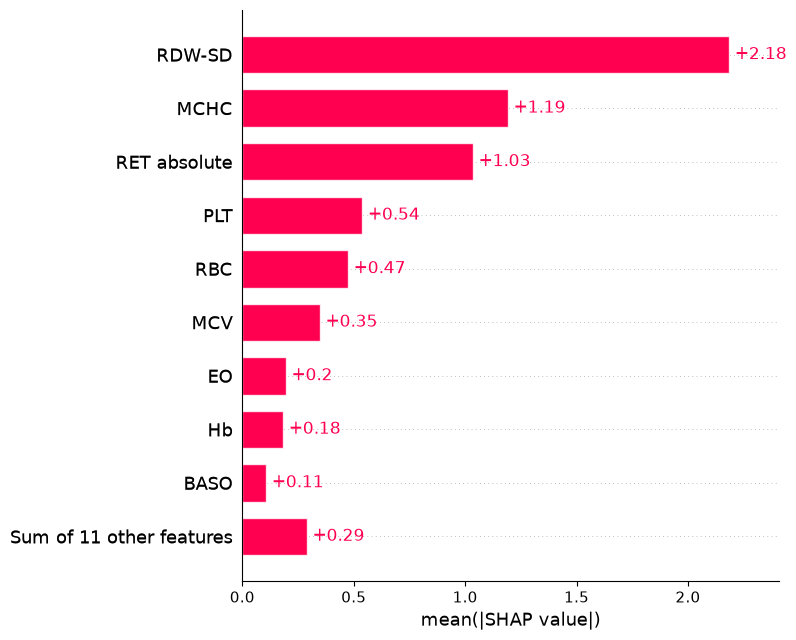

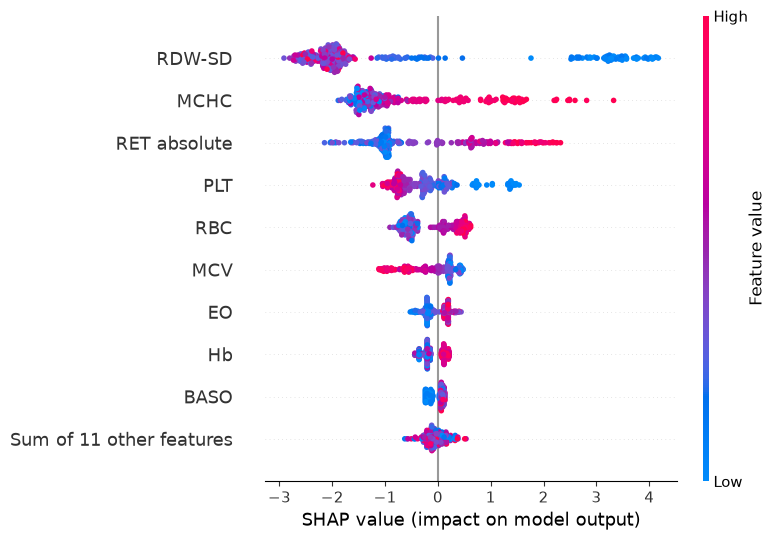

     Feature  Importance
      RDW-SD    2.184650
        MCHC    1.191853
RET absolute    1.034712
         PLT    0.537988
         RBC    0.474214
         MCV    0.347880
          EO    0.195009
          Hb    0.182908
        BASO    0.106739
         MFR    0.060538
       LYMPH    0.054655
        NEUT    0.045360
        MONO    0.044134
      RDW-CV    0.025865
         HFR    0.022097
         IRF    0.021816
         MCH    0.015042
         HCT    0.000000
       RET %    0.000000
         LFR    0.000000

Variables retenues pour le score diagnostique (top 3 SHAP) : ['RDW-SD', 'MCHC', 'RET absolute']


In [10]:
# ===== SHAP (feature importance / selection des variables du score) =====
xgb_full = make_xgboost()
xgb_full.fit(X, y)

explainer = shap.Explainer(xgb_full)
shap_values = explainer(X)

shap.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.show()

shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.show()

shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(shap_values.values).mean(axis=0),
}).sort_values("Importance", ascending=False)

print(shap_importance.to_string(index=False))

SCORE_FEATURES = shap_importance["Feature"].head(3).tolist()
print(f"\nVariables retenues pour le score diagnostique (top 3 SHAP) : {SCORE_FEATURES}")

In [11]:
# ===== Construction du score diagnostique final =====
# Split fixe 70% entrainement / 30% validation : le score final doit etre UNE
# formule fixe entrainee uniquement sur les 70%, jamais evaluee sur les
# donnees qui ont servi a la construire.
X_train70, X_val30, y_train70, y_val30 = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_score_train = X_train70[SCORE_FEATURES]
X_score_val = X_val30[SCORE_FEATURES]

scaler_score = StandardScaler()
X_score_train_scaled = scaler_score.fit_transform(X_score_train)
X_score_val_scaled = scaler_score.transform(X_score_val)

model_score = LogisticRegression(max_iter=1000, random_state=42)
model_score.fit(X_score_train_scaled, y_train70)

coef_std = model_score.coef_[0]
intercept_std = model_score.intercept_[0]

means = scaler_score.mean_
stds = scaler_score.scale_
coef_raw = coef_std / stds
intercept_raw = intercept_std - np.sum(coef_std * means / stds)

def fmt_coef(c):
    # Suffisamment de chiffres significatifs pour que les variables sur une
    # grande echelle brute (ex: RET absolute, en unites/uL) n'affichent pas
    # un coefficient trompeur "0.0000" alors qu'il est juste tres petit.
    return f"{abs(c):.4f}" if abs(c) >= 0.001 else f"{abs(c):.3e}"


terms = " ".join(f"{'+' if c >= 0 else '-'} {fmt_coef(c)}*{f}" for f, c in zip(SCORE_FEATURES, coef_raw))
intercept_term = f"{'+' if intercept_raw >= 0 else '-'} {abs(intercept_raw):.4f}"

print("===== ETAPE 1 : logit (z) - combinaison lineaire, valeurs brutes =====")
print(f"z = {terms} {intercept_term}")
print("Attention : z n'est PAS une probabilite (il n'est pas borne entre 0 et 1).")

print("\n===== ETAPE 2 : probabilite BTM (sigmoide de z) =====")
print("P(BTM) = 1 / (1 + exp(-z))")
print("C'est CETTE probabilite qui doit etre comparee au seuil de decision, pas z directement.")

score_std_method = model_score.decision_function(X_score_train_scaled)
score_raw_method = np.dot(X_score_train.values, coef_raw) + intercept_raw
equivalent = np.allclose(score_std_method, score_raw_method, atol=1e-8)
print(f"\n(verification : formule standardisee et formule brute donnent le meme z : {equivalent})")

print("\n===== EXEMPLE CONCRET (patient median de chaque groupe) =====")
for group_label in ["IDA", "BTM"]:
    typical = data.loc[data["label"] == group_label, SCORE_FEATURES].median()
    z_typical = float(np.dot(typical.values, coef_raw) + intercept_raw)
    p_typical = 1 / (1 + np.exp(-z_typical))
    values_str = ", ".join(f"{f}={typical[f]:.2f}" for f in SCORE_FEATURES)
    print(f"Patient median {group_label} ({values_str}) : z = {z_typical:.3f} -> P(BTM) = {p_typical:.4f}")

proba_train70 = model_score.predict_proba(X_score_train_scaled)[:, 1]
proba_val30 = model_score.predict_proba(X_score_val_scaled)[:, 1]

===== ETAPE 1 : logit (z) - combinaison lineaire, valeurs brutes =====
z = - 0.2629*RDW-SD + 0.6656*MCHC + 4.881e-05*RET absolute - 14.2434
Attention : z n'est PAS une probabilite (il n'est pas borne entre 0 et 1).

===== ETAPE 2 : probabilite BTM (sigmoide de z) =====
P(BTM) = 1 / (1 + exp(-z))
C'est CETTE probabilite qui doit etre comparee au seuil de decision, pas z directement.

(verification : formule standardisee et formule brute donnent le meme z : True)

===== EXEMPLE CONCRET (patient median de chaque groupe) =====
Patient median IDA (RDW-SD=46.10, MCHC=29.00, RET absolute=45300.00) : z = -4.848 -> P(BTM) = 0.0078
Patient median BTM (RDW-SD=35.80, MCHC=32.35, RET absolute=93450.00) : z = 2.440 -> P(BTM) = 0.9198


In [12]:
# ===== Seuil de decision (indice de Youden, calcule sur les 70% d'entrainement) =====
# IMPORTANT : ce seuil s'applique a P(BTM) (la probabilite, etape 2 ci-dessus),
# PAS a z (le logit brut, etape 1) - ce sont deux echelles differentes.
score_threshold = youden_threshold(y_train70, proba_train70)
print(f"Seuil optimal (Youden) sur P(BTM) = {score_threshold:.4f}")
print("(calcule uniquement sur les 70% d'entrainement, puis applique tel quel a la validation)")

Seuil optimal (Youden) sur P(BTM) = 0.3496
(calcule uniquement sur les 70% d'entrainement, puis applique tel quel a la validation)


===== Matrice reel / score, validation (n=100, jamais vus a l'entrainement) =====

          Score : IDA  Score : BTM
Reel IDA           80            2
Reel BTM            2           16

Patients correctement diagnostiques : 96/100 (96.0%)
Sensibilite (BTM detectes) : 88.9%
Specificite (IDA detectes) : 97.6%
AUC : 0.9892 (p-value vs 0.5 : 0.00e+00)

===== Extrait patient par patient (10 premiers, validation) =====

  Diagnostic reel Diagnostic score    P(BTM)
0             IDA              IDA  0.033679
1             IDA              IDA  0.059453
2             BTM              BTM  0.931998
3             IDA              IDA  0.111913
4             IDA              IDA  0.068858
5             IDA              IDA  0.210397
6             IDA              IDA  0.006317
7             IDA              IDA  0.027942
8             IDA              IDA  0.024192
9             IDA              IDA  0.004772


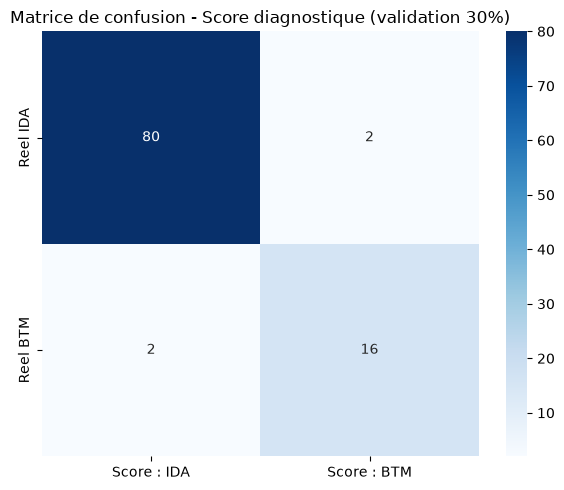

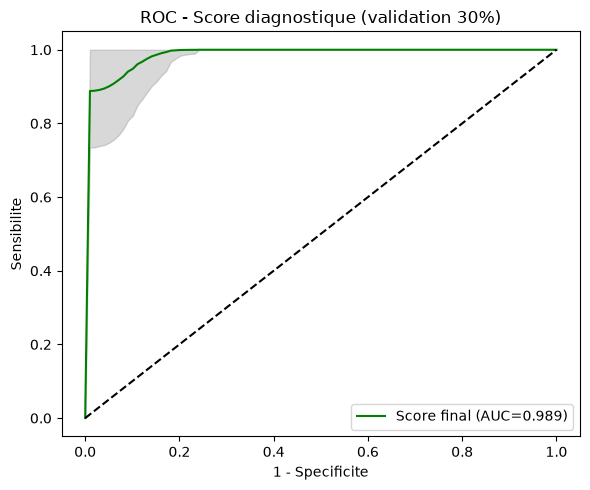

In [13]:
# ===== Validation du score sur les 30% mis de cote (jamais vus a l'entrainement) =====
label_map = {0: "IDA", 1: "BTM"}

y_pred_val30 = (proba_val30 > score_threshold).astype(int)
metrics_score = binary_metrics(y_val30, y_pred_val30, proba_val30)

n1 = int((y_val30 == 1).sum())
n0 = int((y_val30 == 0).sum())
auc_val = metrics_score["auc"]
Q1 = auc_val / (2 - auc_val)
Q2 = 2 * auc_val ** 2 / (1 + auc_val)
se_auc = np.sqrt((auc_val * (1 - auc_val) + (n1 - 1) * (Q1 - auc_val ** 2)
                  + (n0 - 1) * (Q2 - auc_val ** 2)) / (n0 * n1))
if se_auc == 0:
    p_value_score = 0.0
else:
    z = (auc_val - 0.5) / se_auc
    p_value_score = 2 * (1 - norm.cdf(abs(z)))

comparison_val = pd.DataFrame({
    "Diagnostic reel": y_val30.map(label_map).values,
    "Diagnostic score": pd.Series(y_pred_val30, index=y_val30.index).map(label_map).values,
    "P(BTM)": proba_val30,
})

cm_score = confusion_matrix(y_val30, y_pred_val30)
cm_score_df = pd.DataFrame(cm_score, index=["Reel IDA", "Reel BTM"], columns=["Score : IDA", "Score : BTM"])
print("===== Matrice reel / score, validation (n={}, jamais vus a l'entrainement) =====\n".format(len(y_val30)))
print(cm_score_df)

n_correct_val = int((y_pred_val30 == y_val30.values).sum())
print(f"\nPatients correctement diagnostiques : {n_correct_val}/{len(y_val30)} ({metrics_score['accuracy']*100:.1f}%)")
print(f"Sensibilite (BTM detectes) : {metrics_score['sensitivity']*100:.1f}%")
print(f"Specificite (IDA detectes) : {metrics_score['specificity']*100:.1f}%")
print(f"AUC : {auc_val:.4f} (p-value vs 0.5 : {p_value_score:.2e})")

print("\n===== Extrait patient par patient (10 premiers, validation) =====\n")
print(comparison_val.head(10).to_string())

plt.figure(figsize=(6, 5))
sns.heatmap(cm_score_df, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion - Score diagnostique (validation 30%)")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_val30, proba_val30)
n_boot = 1000
rng = np.random.RandomState(42)
mean_fpr = np.linspace(0, 1, 100)
tprs = []
y_val30_arr = y_val30.values
for _ in range(n_boot):
    idx = rng.randint(0, len(y_val30_arr), len(y_val30_arr))
    if len(np.unique(y_val30_arr[idx])) < 2:
        continue
    f, t, _ = roc_curve(y_val30_arr[idx], proba_val30[idx])
    ti = np.interp(mean_fpr, f, t)
    ti[0] = 0.0
    tprs.append(ti)
mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)
upper = np.minimum(mean_tpr + 1.96 * std_tpr, 1)
lower = np.maximum(mean_tpr - 1.96 * std_tpr, 0)

plt.figure(figsize=(6, 5))
plt.plot(mean_fpr, mean_tpr, color="green", label=f"Score final (AUC={auc_val:.3f})")
plt.fill_between(mean_fpr, lower, upper, color="gray", alpha=0.3)
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("1 - Specificite")
plt.ylabel("Sensibilite")
plt.title("ROC - Score diagnostique (validation 30%)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Robustesse du score sur 50 splits 70/30 differents (memes 3 variables, seuil recalcule a chaque fois) :

       accuracy  sensitivity  specificity      auc
count   50.0000      50.0000      50.0000  50.0000
mean     0.9588       0.9300       0.9651   0.9869
std      0.0240       0.0548       0.0341   0.0159
min      0.8800       0.8333       0.8537   0.9512
25%      0.9525       0.8889       0.9543   0.9885
50%      0.9600       0.9444       0.9756   0.9939
75%      0.9700       0.9861       0.9878   0.9959
max      1.0000       1.0000       1.0000   1.0000

AUC >= 0.999 dans 8/50 splits
Seed officielle (42) : AUC = 0.9892


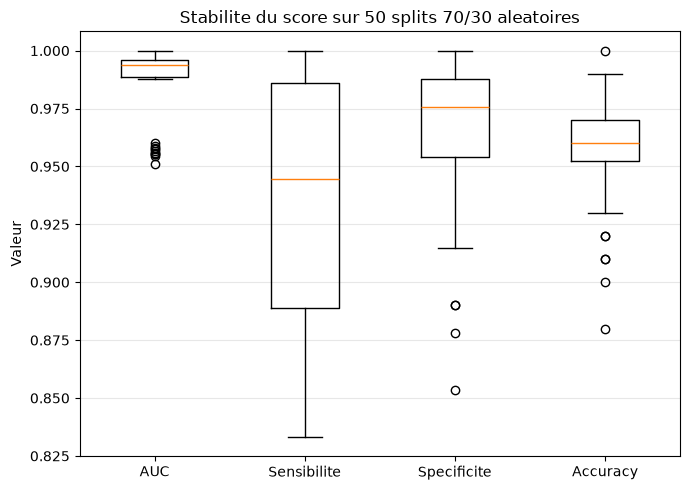

In [14]:
# ===== Robustesse du score : le split 70/30 officiel est-il un coup de chance ? =====
N_ROBUSTNESS = 50
robustness_rows = []

for seed in range(N_ROBUSTNESS):
    Xr_train, Xr_val, yr_train, yr_val = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=seed
    )

    Xr_score_train = Xr_train[SCORE_FEATURES]
    Xr_score_val = Xr_val[SCORE_FEATURES]

    scaler_r = StandardScaler()
    Xr_train_scaled = scaler_r.fit_transform(Xr_score_train)
    Xr_val_scaled = scaler_r.transform(Xr_score_val)

    model_r = LogisticRegression(max_iter=1000, random_state=42)
    model_r.fit(Xr_train_scaled, yr_train)

    proba_r_train = model_r.predict_proba(Xr_train_scaled)[:, 1]
    proba_r_val = model_r.predict_proba(Xr_val_scaled)[:, 1]

    thr_r = youden_threshold(yr_train, proba_r_train)
    pred_r_val = (proba_r_val > thr_r).astype(int)

    m = binary_metrics(yr_val, pred_r_val, proba_r_val)
    m["seed"] = seed
    robustness_rows.append(m)

robustness_df = pd.DataFrame(robustness_rows)

print(f"Robustesse du score sur {N_ROBUSTNESS} splits 70/30 differents (memes 3 variables, seuil recalcule a chaque fois) :\n")
print(robustness_df[["accuracy", "sensitivity", "specificity", "auc"]].describe().round(4).to_string())

n_perfect_auc = (robustness_df["auc"] >= 0.999).sum()
print(f"\nAUC >= 0.999 dans {n_perfect_auc}/{N_ROBUSTNESS} splits")
print(f"Seed officielle (42) : AUC = {robustness_df.loc[robustness_df['seed'] == 42, 'auc'].values[0]:.4f}")

plt.figure(figsize=(7, 5))
plt.boxplot(
    [robustness_df["auc"], robustness_df["sensitivity"], robustness_df["specificity"], robustness_df["accuracy"]],
    tick_labels=["AUC", "Sensibilite", "Specificite", "Accuracy"],
)
plt.title(f"Stabilite du score sur {N_ROBUSTNESS} splits 70/30 aleatoires")
plt.ylabel("Valeur")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [15]:
# ===== Tableau recapitulatif unique (base de la heatmap) =====
summary_rows = []
nir = max(y.mean(), 1 - y.mean())

for label in ["XGBoost", "Elastic Net"]:
    m = model_metrics[label]
    acc_mean, acc_lo, acc_hi = summarize(m, "accuracy")
    auc_mean, auc_lo, auc_hi = summarize(m, "auc")
    p_val = binomtest(int(acc_mean * len(y)), len(y), nir, alternative="greater").pvalue
    summary_rows.append({
        "Modele": label,
        "Accuracy": acc_mean,
        "Sensibilite": np.mean([x["sensitivity"] for x in m]),
        "Specificite": np.mean([x["specificity"] for x in m]),
        "Precision": np.mean([x["precision"] for x in m]),
        "NPV": np.mean([x["npv"] for x in m]),
        "F1": np.mean([x["f1"] for x in m]),
        "AUC": auc_mean, "AUC_low": auc_lo, "AUC_high": auc_hi,
        "CER": 1 - acc_mean, "p-value": p_val,
    })

for name in INDEX_DEFINITIONS:
    m = index_metrics[name]
    acc_mean, acc_lo, acc_hi = summarize(m, "accuracy")
    auc_mean, auc_lo, auc_hi = summarize(m, "auc")
    p_val = binomtest(int(acc_mean * len(y)), len(y), nir, alternative="greater").pvalue
    summary_rows.append({
        "Modele": name,
        "Accuracy": acc_mean,
        "Sensibilite": np.mean([x["sensitivity"] for x in m]),
        "Specificite": np.mean([x["specificity"] for x in m]),
        "Precision": np.mean([x["precision"] for x in m]),
        "NPV": np.mean([x["npv"] for x in m]),
        "F1": np.mean([x["f1"] for x in m]),
        "AUC": auc_mean, "AUC_low": auc_lo, "AUC_high": auc_hi,
        "CER": 1 - acc_mean, "p-value": p_val,
    })

summary_rows.append({
    "Modele": "Score diagnostique (validation 30%)",
    "Accuracy": metrics_score["accuracy"], "Sensibilite": metrics_score["sensitivity"],
    "Specificite": metrics_score["specificity"], "Precision": metrics_score["precision"],
    "NPV": metrics_score["npv"], "F1": metrics_score["f1"], "AUC": metrics_score["auc"],
    "AUC_low": np.nan, "AUC_high": np.nan, "CER": 1 - metrics_score["accuracy"],
    "p-value": p_value_score,
})

summary_df = pd.DataFrame(summary_rows).sort_values("AUC", ascending=False).reset_index(drop=True)

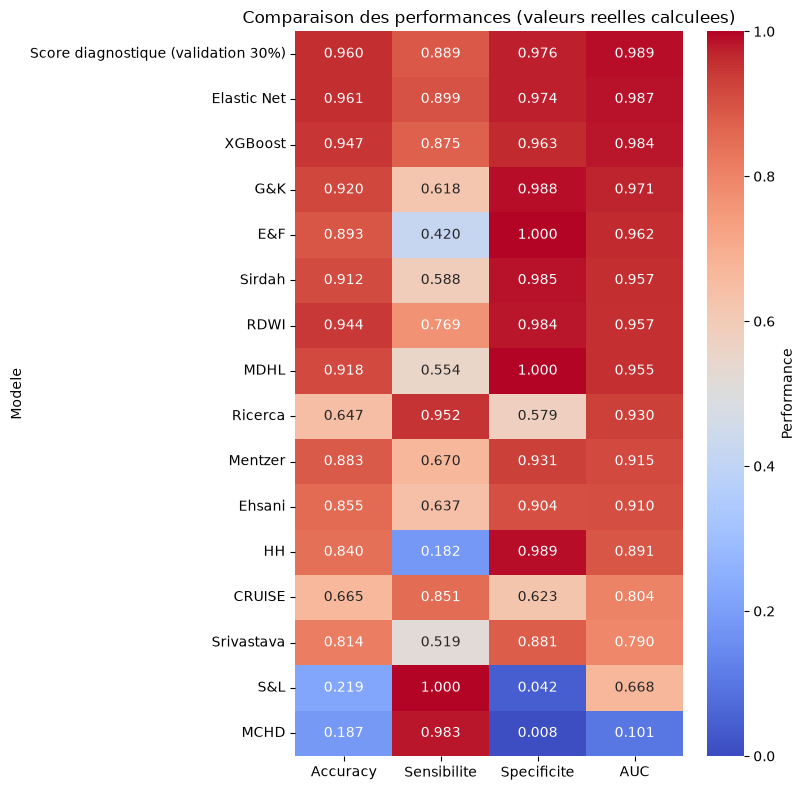

In [16]:
# ===== Heatmap comparative (regeneree a partir des vraies valeurs calculees) =====
heatmap_df = summary_df.set_index("Modele")[["Accuracy", "Sensibilite", "Specificite", "AUC"]].dropna()

plt.figure(figsize=(8, max(4, 0.5 * len(heatmap_df))))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="coolwarm", vmin=0, vmax=1,
            cbar_kws={"label": "Performance"})
plt.title("Comparaison des performances (valeurs reelles calculees)")
plt.tight_layout()
plt.show()